# Gene context

Data retrieved with AnnoView (Wei et al., 2024; DOI: 10.1093/bib/bbae229)

In [32]:
import os
from pathlib import Path
import re

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from dna_features_viewer import GraphicFeature, GraphicRecord

cwd = os.getcwd()
if cwd.endswith('notebook'):
    os.chdir('..')
    cwd = os.getcwd()

In [6]:
sns.set_palette('colorblind')
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.8)
plt.rcParams['font.family'] = 'Helvetica'

palette = sns.color_palette().as_hex()

data_folder = Path('./data')
assert data_folder.is_dir()

figures_folder = Path('./figures')
assert figures_folder.is_dir()

In [151]:
gtdb_metadata = pd.read_csv(data_folder / 'gtdb_metadata.csv', index_col='ncbi_accession')

In [22]:
pgh_proteins = pd.read_csv(data_folder / 'pgh_proteins.csv')
pgh_proteins.head()

,assembly_accession,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,ncbi_organism_name,protein_id,pgh_architecture
0,GCA_003663345.1,Archaea,Aenigmatarchaeota,Aenigmatarchaeia,PWEA01,B50-G16,B50-G16,B50-G16 sp003663345,Candidatus Aenigmarchaeota archaeon,RLJ01288.1,PG_binding_3+Glyco_hydro_108
1,GCA_018304545.1,Archaea,Aenigmatarchaeota,Aenigmatarchaeia,CG10238-14,CG10238-14,JAGVVZ01,JAGVVZ01 sp018304545,Candidatus Aenigmarchaeota archaeon,MBS3052716.1,LysM+Amidase_2
2,GCA_025058005.1,Archaea,Aenigmatarchaeota,Aenigmatarchaeia,CG10238-14,CG10238-14,JAHLMN01,JAHLMN01 sp025058005,Candidatus Aenigmarchaeota archaeon,MCS7135447.1,LysM+NLPC_P60
3,GCA_015661515.1,Archaea,Aenigmatarchaeota,Aenigmatarchaeia,Aenigmatarchaeales,SZUA-1535,SZUA-1535,SZUA-1535 sp015661515,Nanoarchaeota archaeon,HIQ49991.1,PG_binding_3+Glyco_hydro_108
4,GCA_902384455.1,Archaea,Altiarchaeota,Altiarchaeia,IMC4,SCGC-AAA252-I15,CABMCB01,CABMCB01 sp902384455,uncultured archaeon,VVB52780.1,PG_binding_3+Glyco_hydro_108


In [24]:
J2ZZK6_like_proteins = pgh_proteins[
    (pgh_proteins['domain'] == 'Archaea') &
    (pgh_proteins['pgh_architecture'] == 'PG_binding_1+Peptidase_M23')
]
J2ZZK6_like_proteins

,assembly_accession,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,ncbi_organism_name,protein_id,pgh_architecture
16,GCF_000710615.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haladaptataceae,Haladaptatus,Haladaptatus cibarius,Haladaptatus cibarius D43,WP_049971528.1,PG_binding_1+Peptidase_M23
18,GCF_900156425.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haladaptataceae,Haladaptatus,Haladaptatus litoreus,Haladaptatus litoreus,WP_076427578.1,PG_binding_1+Peptidase_M23
29,GCF_020618475.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haladaptataceae,Haladaptatus,Haladaptatus sp020618475,Haladaptatus sp. PSR5,WP_255766967.1,PG_binding_1+Peptidase_M23
30,GCF_021083305.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haladaptataceae,Haladaptatus,Haladaptatus sp021083305,Haladaptatus sp. DYF46,WP_231184600.1,PG_binding_1+Peptidase_M23
52,GCF_000283335.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloferacaceae,Halogranum,Halogranum rubrum,Halogranum salarium B-1,WP_157572895.1,PG_binding_1+Peptidase_M23
131,GCA_016211165.1,Archaea,Nanoarchaeota,Nanoarchaeia,Woesearchaeales,JAGWAF01,JACQSU01,JACQSU01 sp016211165,Candidatus Woesearchaeota archaeon,MBI4449356.1,PG_binding_1+Peptidase_M23


In [25]:
J2ZJU5_like_proteins = pgh_proteins[
    (pgh_proteins['domain'] == 'Archaea') &
    (pgh_proteins['pgh_architecture'] == 'PG_binding_1+Glucosaminidase')
]
J2ZJU5_like_proteins

,assembly_accession,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,ncbi_organism_name,protein_id,pgh_architecture
17,GCF_000710615.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haladaptataceae,Haladaptatus,Haladaptatus cibarius,Haladaptatus cibarius D43,WP_158413663.1,PG_binding_1+Glucosaminidase
21,GCF_900156425.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haladaptataceae,Haladaptatus,Haladaptatus litoreus,Haladaptatus litoreus,WP_175609653.1,PG_binding_1+Glucosaminidase
24,GCF_020700235.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haladaptataceae,Haladaptatus,Haladaptatus pallidirubidus,Haladaptatus pallidirubidus,WP_265338400.1,PG_binding_1+Glucosaminidase
45,GCF_023074835.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloarculaceae,Halomarina,Halomarina salina,Halomarina salina,WP_247418429.1,PG_binding_1+Glucosaminidase
50,GCF_002844195.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloferacaceae,Halegenticoccus,Halegenticoccus soli,Halegenticoccus soli,WP_143423131.1,PG_binding_1+Glucosaminidase
51,GCF_000283335.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloferacaceae,Halogranum,Halogranum rubrum,Halogranum salarium B-1,WP_009365375.1,PG_binding_1+Glucosaminidase
130,GCA_016211165.1,Archaea,Nanoarchaeota,Nanoarchaeia,Woesearchaeales,JAGWAF01,JACQSU01,JACQSU01 sp016211165,Candidatus Woesearchaeota archaeon,MBI4448463.1,PG_binding_1+Glucosaminidase


In [46]:
all_accessions = set(J2ZZK6_like_proteins['assembly_accession'].unique()) | set(J2ZJU5_like_proteins['assembly_accession'].unique())

df = pd.concat([
    J2ZZK6_like_proteins,
    J2ZJU5_like_proteins,
])[['assembly_accession', 'gtdb_family', 'gtdb_genus']].sort_values(
    ['gtdb_family', 'gtdb_genus', 'assembly_accession']
).drop_duplicates('assembly_accession')

h_salarium_accession = 'GCF_000283335.1'
accessions = [
    h_salarium_accession,
    'GCF_002844195.1',
] + df[~df['assembly_accession'].isin([h_salarium_accession, 'GCF_002844195.1'])]['assembly_accession'].values.tolist()
accessions

['GCF_000283335.1',
 'GCF_002844195.1',
 'GCF_000710615.1',
 'GCF_020618475.1',
 'GCF_020700235.1',
 'GCF_021083305.1',
 'GCF_900156425.1',
 'GCF_023074835.1',
 'GCA_016211165.1']

In [99]:
def parse_gff(path : Path):
    gff_csv = pd.read_csv(
        path,
        sep='\t',
        comment='#',
        header=None,
        names=[
            'contig_id',
            'source',
            'type',
            'start',
            'end',
            'na1',
            'strand',
            'na2',
            'metadata',
        ],
    )

    def parse_protein_id(metadata : str):
        m = re.match(r'^.*protein_id=([^;]+).*$', metadata)
        if m is not None:
            return m[1]
        else:
            return None
        
    def parse_description(metadata : str):
        m = re.match(r'^.*product=([^;]+).*$', metadata)
        if m is not None:
            return m[1]
        else:
            return None

    gff_csv = gff_csv[gff_csv['type'] == 'CDS'].reset_index(drop=True)
    gff_csv['protein_id'] = gff_csv['metadata'].apply(parse_protein_id)
    gff_csv['description'] = gff_csv['metadata'].apply(parse_description)

    return gff_csv.drop_duplicates(['contig_id', 'protein_id']).reset_index(drop=True)


In [100]:
accession_to_annotations = {}
for accession in accessions:
    base_path = data_folder / 'gene_context' / 'annotations'
    gff_path = list(base_path.glob(f'*{accession}*.gff.gz'))[0]
    pfam_path = list(base_path.glob(f'*{accession}*Pfam-A.csv.gz'))[0]
    tigr_path = list(base_path.glob(f'*{accession}*TIGR.csv.gz'))[0]

    gff = parse_gff(gff_path)
    pfam = pd.read_csv(pfam_path, index_col='protein_id')
    tigr = pd.read_csv(tigr_path, index_col='protein_id')

    def get_domains(domains_df, protein_id):
        if protein_id not in domains_df.index:
            return None
        else:
            df = domains_df.loc[[protein_id]]
            return ', '.join(sorted(df['hmm_query'].unique().tolist()))

    gff['pfam'] = gff['protein_id'].apply(lambda p: get_domains(pfam, p))
    gff['tigr'] = gff['protein_id'].apply(lambda p: get_domains(tigr, p))

    accession_to_annotations[accession] = gff.set_index('protein_id')

In [101]:
accession_to_annotations['GCF_000283335.1'].head()

,contig_id,source,type,start,end,na1,strand,na2,metadata,description,pfam,tigr
protein_id,,,,,,,,,,,,
WP_009365345.1,NZ_ALJD01000001.1,Protein Homology,CDS,356,916,.,+,0,ID=cds-WP_009365345.1;Parent=gene-HSB1_RS00005...,TATA-box-binding protein,TBP,None
WP_157572802.1,NZ_ALJD01000001.1,GeneMarkS-2+,CDS,1263,1823,.,+,0,ID=cds-WP_157572802.1;Parent=gene-HSB1_RS00010...,hypothetical protein,None,None
WP_049893380.1,NZ_ALJD01000001.1,Protein Homology,CDS,2076,3281,.,-,0,ID=cds-WP_049893380.1;Parent=gene-HSB1_RS00015...,orc1/cdc6 family replication initiation protein,"AAA, AAA_16, AAA_22, AAA_5, Cdc6_C, Sigma54_ac...",TIGR02928
WP_009365348.1,NZ_ALJD01000001.1,Protein Homology,CDS,4444,5031,.,+,0,ID=cds-WP_009365348.1;Parent=gene-HSB1_RS00020...,hypothetical protein,None,None
WP_085942424.1,NZ_ALJD01000001.1,Protein Homology,CDS,5433,5993,.,+,0,ID=cds-WP_085942424.1;Parent=gene-HSB1_RS00025...,hypothetical protein,None,None


In [102]:
df = accession_to_annotations['GCF_000283335.1']
df[df['pfam'] == 'PG_binding_1, Peptidase_M23']

,contig_id,source,type,start,end,na1,strand,na2,metadata,description,pfam,tigr
protein_id,,,,,,,,,,,,
WP_157572895.1,NZ_ALJD01000008.1,Protein Homology,CDS,48359,49333,.,+,0,ID=cds-WP_157572895.1;Parent=gene-HSB1_RS13735...,peptidoglycan-binding protein,"PG_binding_1, Peptidase_M23",None


### J2ZZK6

In [147]:
J2ZZK6_accessions = set(J2ZZK6_like_proteins['assembly_accession'].unique())
J2ZZK6_annotations = []

n_upstream = n_downstream = 13_000
for accession in accessions:
    if accession not in J2ZZK6_accessions:
        continue

    annotations = accession_to_annotations[accession]
    
    protein_id = annotations[annotations['pfam'] == 'PG_binding_1, Peptidase_M23'].index[0]
    row = annotations.loc[protein_id]

    contig_id = row['contig_id']
    start = max(row['start'] - n_upstream, 1)
    end = row['end'] + n_downstream

    df = annotations[
        (annotations['contig_id'] == contig_id) &
        (annotations['start'] >= start) &
        (annotations['start'] < end) &
        (annotations['end'] > start) &
        (annotations['end'] <= end)
    ]

    J2ZZK6_annotations.append((accession, df))
    

### J2ZJU5

In [155]:
J2ZJU5_accessions = set(J2ZJU5_like_proteins['assembly_accession'].unique())
J2ZJU5_annotations = []

n_upstream = n_downstream = 13_000
for accession in accessions:
    if accession not in J2ZJU5_accessions:
        continue

    annotations = accession_to_annotations[accession]
    
    protein_id = annotations[annotations['pfam'] == 'Glucosaminidase, PG_binding_1'].index[0]
    row = annotations.loc[protein_id]

    contig_id = row['contig_id']
    start = max(row['start'] - n_upstream, 1)
    end = row['end'] + n_downstream

    df = annotations[
        (annotations['contig_id'] == contig_id) &
        (annotations['start'] >= start) &
        (annotations['start'] < end) &
        (annotations['end'] > start) &
        (annotations['end'] <= end)
    ]

    J2ZJU5_annotations.append((accession, df))

### Plot

In [143]:
def plot_genes(aoi_df, ax=None, figure_width=20):
    features = []
    start = aoi_df['start'].min()
    end = aoi_df['end'].max()
    length = end - start + 1

    for _, row in aoi_df.iterrows():
        label = row['description']
    
        color = '#add8e6'
        if label == 'hypothetical protein':
            color = '#cccccc'
        
        is_core_peptide = row['pfam'] is not None and 'PG_binding_1' in row['pfam']
        if is_core_peptide:
            color = '#98fb98'

        features.append(
            GraphicFeature(
                start=row.start, 
                end=row.end, 
                strand=1 if row.strand == '+' else -1, 
                color=color,
                label=label,
            )
        )
    
    record = GraphicRecord(first_index=start, sequence_length=length, features=features)
    ax, _ = record.plot(figure_width=figure_width, ax=ax, with_ruler=True)
    ax.grid(False)
    return ax

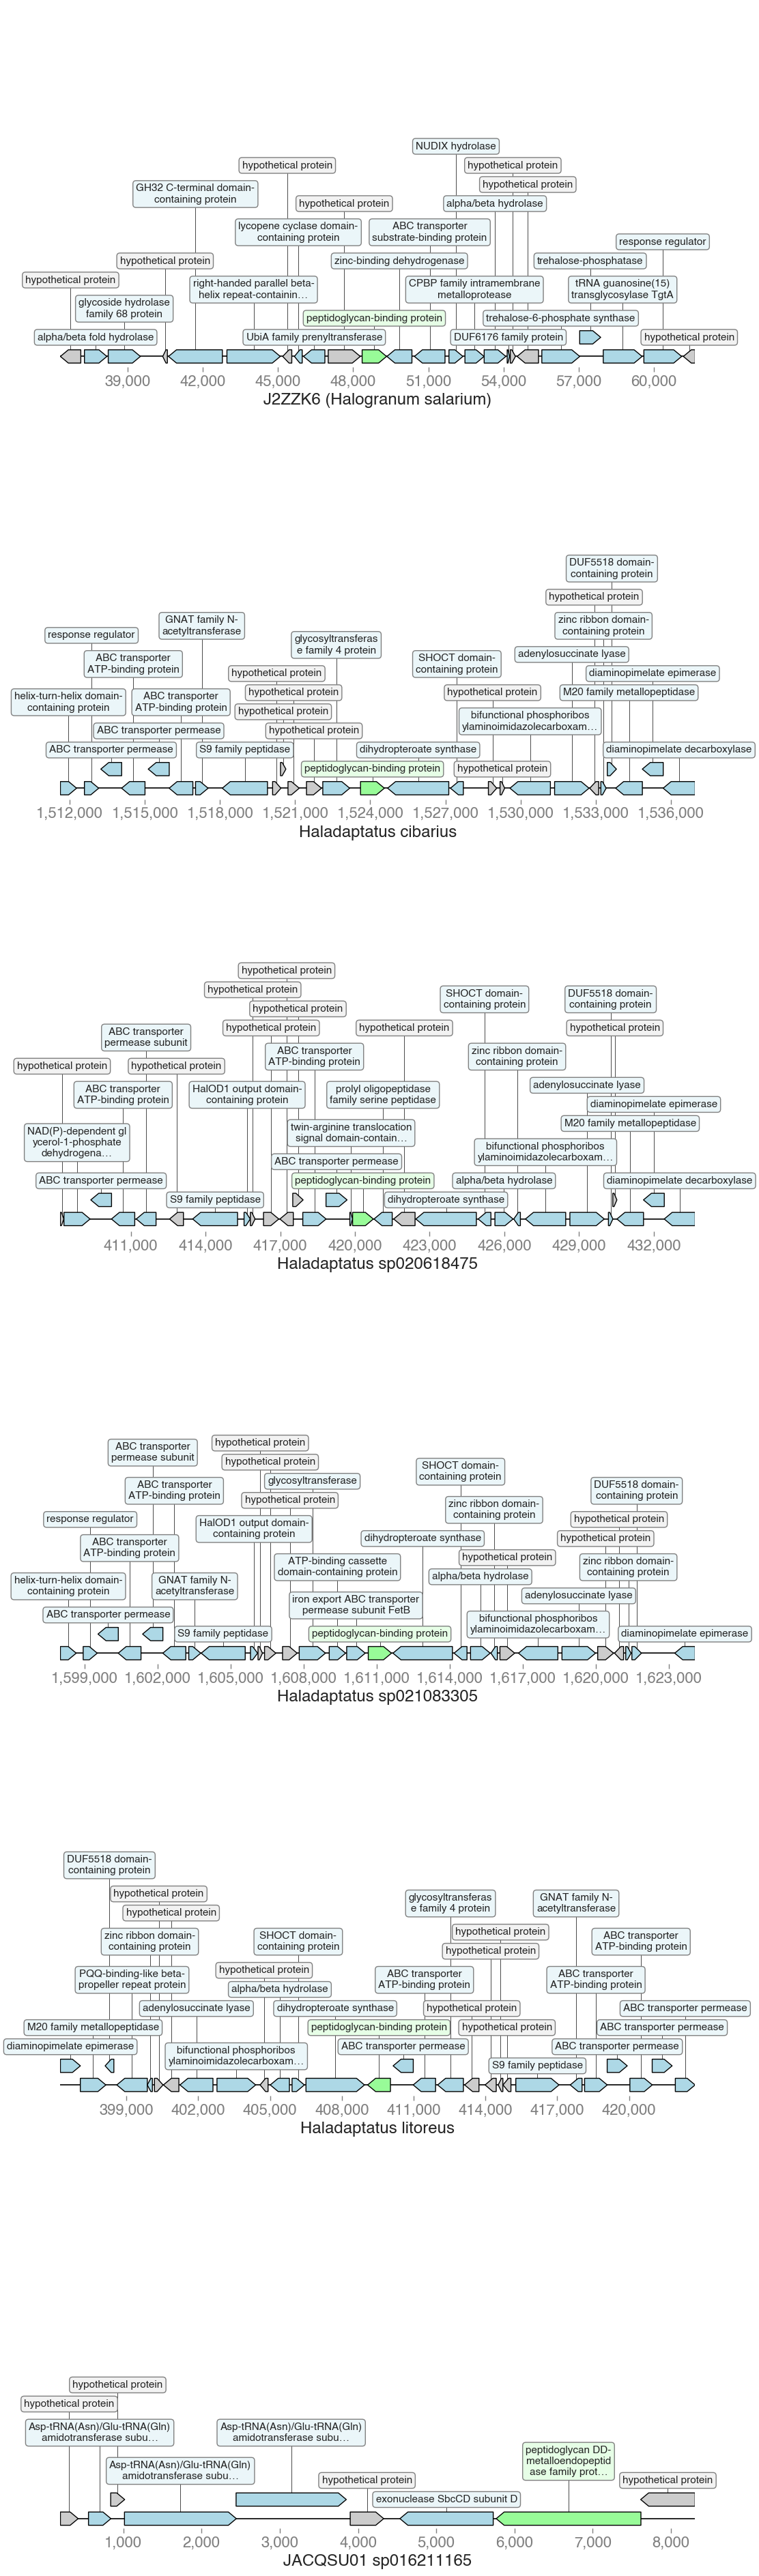

In [152]:
f, axes = plt.subplots(len(J2ZZK6_annotations), 1, figsize=(12, 8 * len(J2ZZK6_annotations)))
axes = axes.flatten()

for i, (accession, annotations) in enumerate(J2ZZK6_annotations):
    ax = axes[i]
    plot_genes(annotations, ax=ax);

    if i == 0:
        ax.set_xlabel('J2ZZK6 (Halogranum salarium)');
    else:
        ax.set_xlabel(gtdb_metadata.loc[accession, 'gtdb_species']);

plt.gcf().savefig(figures_folder / 'gene_context' / 'J2ZZK6.pdf', dpi=300, bbox_inches='tight');

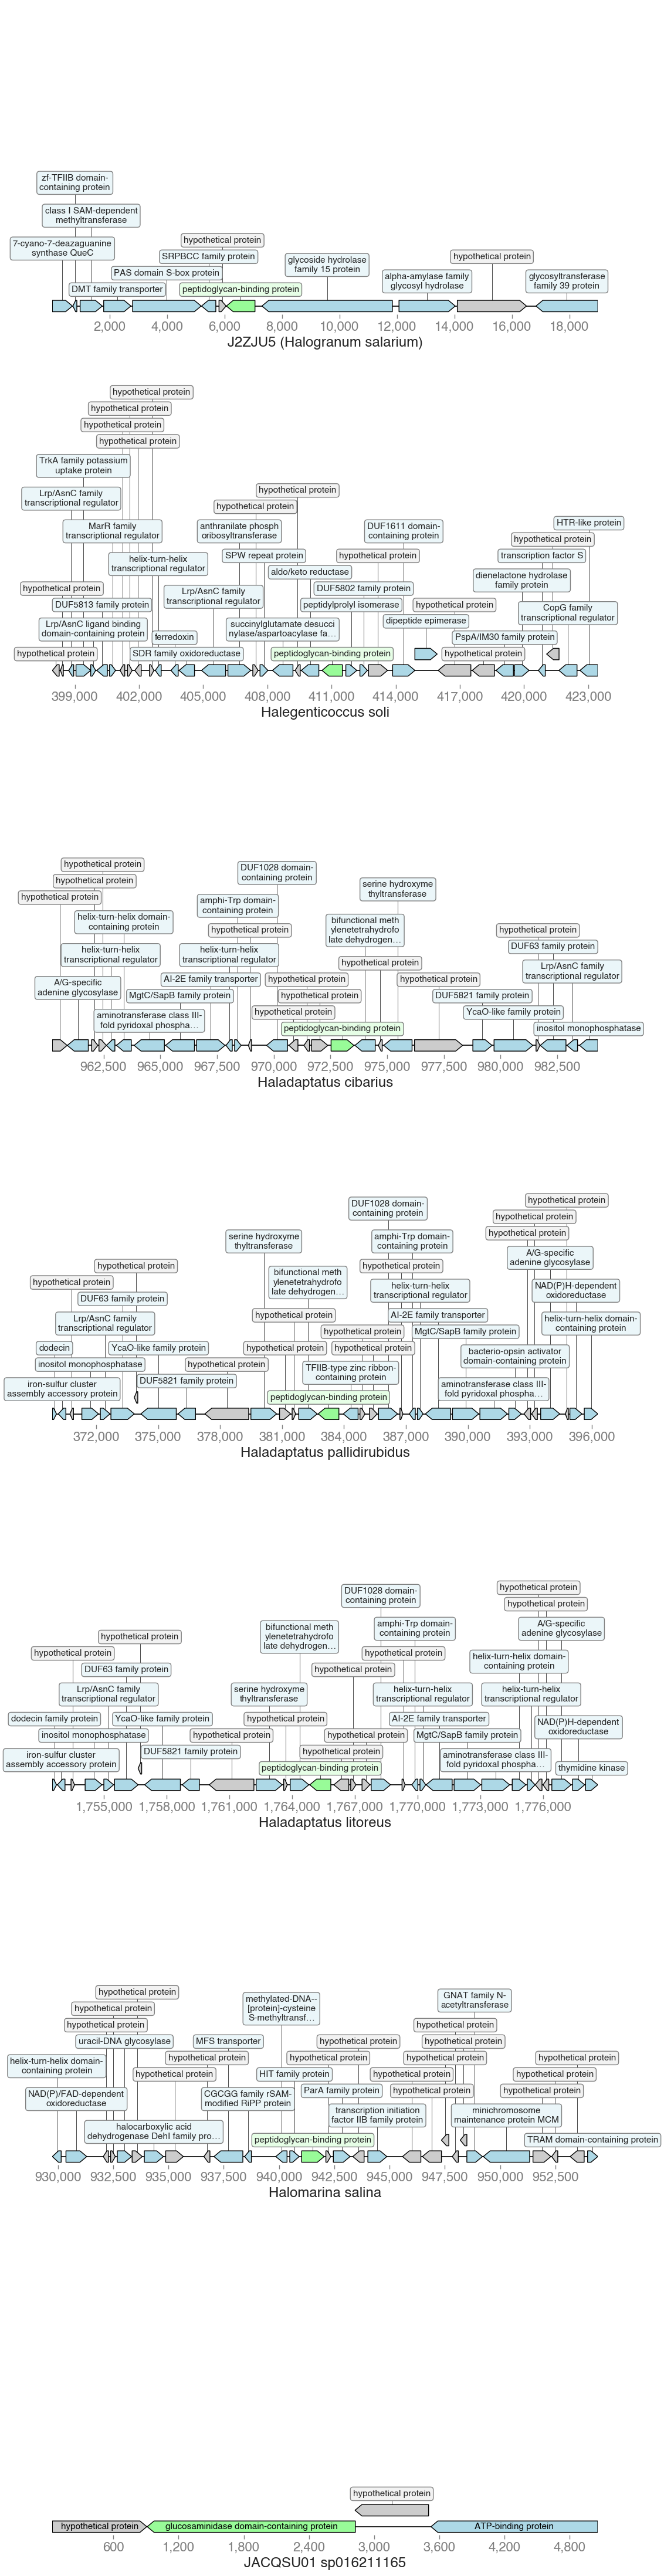

In [156]:
f, axes = plt.subplots(len(J2ZJU5_annotations), 1, figsize=(12, 8 * len(J2ZJU5_annotations)))
axes = axes.flatten()

for i, (accession, annotations) in enumerate(J2ZJU5_annotations):
    ax = axes[i]
    plot_genes(annotations, ax=ax);

    if i == 0:
        ax.set_xlabel('J2ZJU5 (Halogranum salarium)');
    else:
        ax.set_xlabel(gtdb_metadata.loc[accession, 'gtdb_species']);

plt.gcf().savefig(figures_folder / 'gene_context' / 'J2ZJU5.pdf', dpi=300, bbox_inches='tight');